Device: cpu


100%|██████████| 562M/562M [00:58<00:00, 9.64MB/s] 


Batch x.shape: torch.Size([128, 1, 28, 28]), y.shape: torch.Size([128])
x.min: -1.000, x.max: 1.000, unique(y): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 17, 18,
        19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
        38, 39, 40, 41, 42, 43, 44, 45, 46])
Число классов: 47

Эксперимент E1
Epoch  1: train_loss=1.1392, train_acc=0.6652 | val_loss=0.7465, val_acc=0.7686
Epoch  2: train_loss=0.6347, train_acc=0.7928 | val_loss=0.6078, val_acc=0.8073
Epoch  3: train_loss=0.5260, train_acc=0.8233 | val_loss=0.5456, val_acc=0.8173
Epoch  4: train_loss=0.4644, train_acc=0.8399 | val_loss=0.5256, val_acc=0.8239
Epoch  5: train_loss=0.4226, train_acc=0.8514 | val_loss=0.5044, val_acc=0.8345
Epoch  6: train_loss=0.3930, train_acc=0.8593 | val_loss=0.5001, val_acc=0.8344
Epoch  7: train_loss=0.3654, train_acc=0.8662 | val_loss=0.4933, val_acc=0.8375
Epoch  8: train_loss=0.3476, train_acc=0.8715 | val_loss=0.5063, val_acc=0.8353
Epoch  9:

/var/folders/5h/zshkg9_j4z95z0wj2l0ghng00000gn/T/ipykernel_23932/4106597116.py:212: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs_df = pd.concat([runs_df, new_row], ignore_index=True)


Epoch  1: train_loss=1.3868, train_acc=0.5950 | val_loss=0.7773, val_acc=0.7585
Epoch  2: train_loss=0.8568, train_acc=0.7305 | val_loss=0.6412, val_acc=0.7950
Epoch  3: train_loss=0.7505, train_acc=0.7587 | val_loss=0.5880, val_acc=0.8123
Epoch  4: train_loss=0.6960, train_acc=0.7724 | val_loss=0.5485, val_acc=0.8215
Epoch  5: train_loss=0.6617, train_acc=0.7825 | val_loss=0.5292, val_acc=0.8272
Epoch  6: train_loss=0.6323, train_acc=0.7895 | val_loss=0.5126, val_acc=0.8312
Epoch  7: train_loss=0.6133, train_acc=0.7945 | val_loss=0.5057, val_acc=0.8322
Epoch  8: train_loss=0.5953, train_acc=0.7996 | val_loss=0.4991, val_acc=0.8328
Epoch  9: train_loss=0.5846, train_acc=0.8029 | val_loss=0.4854, val_acc=0.8378
Epoch 10: train_loss=0.5711, train_acc=0.8047 | val_loss=0.4811, val_acc=0.8392
Epoch 11: train_loss=0.5654, train_acc=0.8086 | val_loss=0.4755, val_acc=0.8396
Epoch 12: train_loss=0.5521, train_acc=0.8107 | val_loss=0.4754, val_acc=0.8399
Epoch 13: train_loss=0.5469, train_acc=0

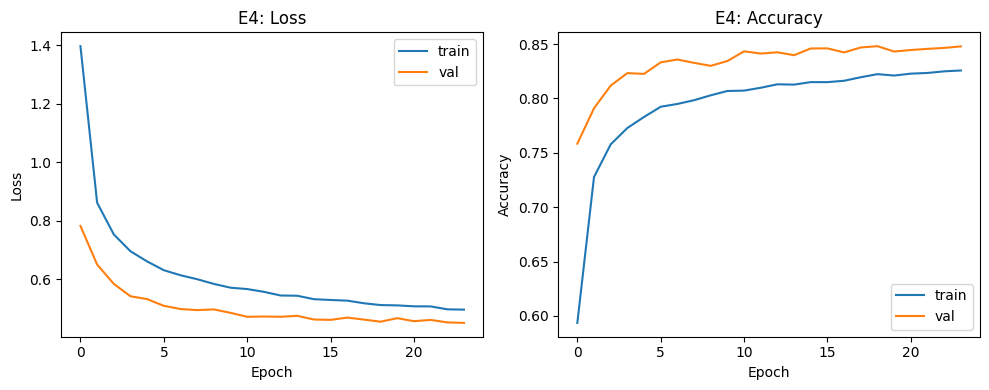

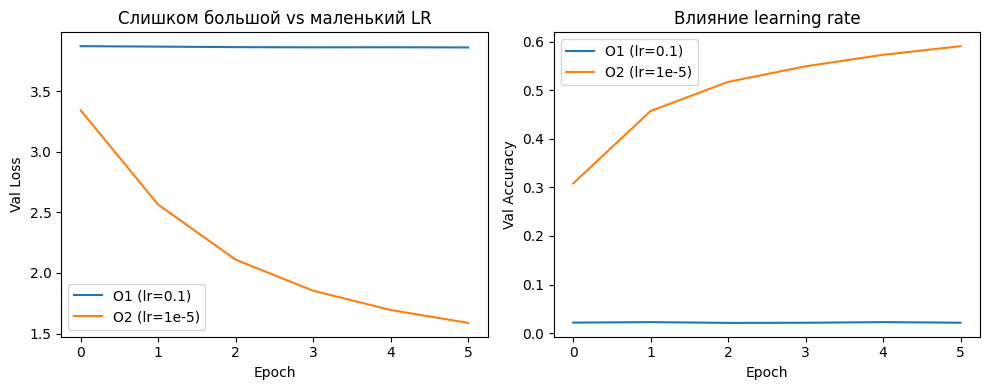

Test Loss: 0.4673, Test Accuracy: 0.8427


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from pathlib import Path

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Фиксируем seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset_full = torchvision.datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
testset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

val_size = int(0.2 * len(trainset_full))
train_size = len(trainset_full) - val_size
train_dataset, val_dataset = random_split(trainset_full, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(seed))

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

# Sanity check
for x, y in train_loader:
    print(f"Batch x.shape: {x.shape}, y.shape: {y.shape}")
    print(f"x.min: {x.min():.3f}, x.max: {x.max():.3f}, unique(y): {torch.unique(y)}")
    break

num_classes = len(trainset_full.classes)
print(f"Число классов: {num_classes}")


class MLP(nn.Module):
    def __init__(self, hidden_sizes=[512, 256], dropout=0.0, use_batchnorm=False):
        super().__init__()
        # Flatten 28x28 -> 784
        layers = [nn.Flatten()]
        prev_size = 28 * 28
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        total_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


artifacts_dir = Path("./artifacts")
figures_dir = artifacts_dir / "figures"

runs_file = artifacts_dir / "runs.csv"
runs_columns = ["experiment_id", "dataset", "seed", "model_summary", "optimizer",
                "lr", "momentum", "weight_decay", "epochs_trained",
                "best_val_accuracy", "best_val_loss"]
runs_df = pd.DataFrame(columns=runs_columns)


def run_experiment(exp_id, model_kwargs, optimizer_name="Adam", lr=0.001,
                   momentum=0.0, weight_decay=0.0, epochs=20, early_stopping_patience=None):
    print(f"\nЭксперимент {exp_id}")
    model = MLP(**model_kwargs).to(device)

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError("Unknown optimizer")

    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_no_improve = 0
    epochs_trained = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:2d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_no_improve = 0

            if exp_id == "E4":
                torch.save(model.state_dict(), artifacts_dir / "best_model.pt")
        else:
            epochs_no_improve += 1

        # Early stopping
        if early_stopping_patience is not None and epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping на эпохе {epoch}")
            break

    epochs_trained = epoch

    summary = f"hidden={model_kwargs['hidden_sizes']}, ReLU"
    if model_kwargs.get('dropout', 0) > 0:
        summary += f", dropout={model_kwargs['dropout']}"
    if model_kwargs.get('use_batchnorm', False):
        summary += ", BN"

    global runs_df
    new_row = pd.DataFrame([{
        "experiment_id": exp_id,
        "dataset": "EMNIST",
        "seed": seed,
        "model_summary": summary,
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum if optimizer_name == "SGD" else "",
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    }])
    runs_df = pd.concat([runs_df, new_row], ignore_index=True)

    return history, best_val_acc, best_val_loss


hist_E1, _, _ = run_experiment("E1", model_kwargs={"hidden_sizes": [512, 256], "dropout": 0.0, "use_batchnorm": False}, epochs=20)


hist_E2, _, _ = run_experiment("E2", model_kwargs={"hidden_sizes": [512, 256], "dropout": 0.3, "use_batchnorm": False}, epochs=20)

hist_E3, _, _ = run_experiment("E3", model_kwargs={"hidden_sizes": [512, 256], "dropout": 0.0, "use_batchnorm": True}, epochs=20)


best_config = {"hidden_sizes": [512, 256], "dropout": 0.3, "use_batchnorm": False}
hist_E4, best_val_acc_E4, best_val_loss_E4 = run_experiment("E4",
                                                            model_kwargs=best_config,
                                                            epochs=30,
                                                            early_stopping_patience=5)

best_config_json = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": seed,
    "model": {
        "hidden_sizes": best_config["hidden_sizes"],
        "dropout": best_config["dropout"],
        "use_batchnorm": best_config["use_batchnorm"],
        "activation": "ReLU"
    },
    "optimizer": "Adam",
    "lr": 0.001,
    "weight_decay": 0.0,
    "batch_size": batch_size,
    "early_stopping_patience": 5,
    "epochs_trained": int(hist_E4['val_loss'][-1])  # заменится позже
}
with open(artifacts_dir / "best_config.json", "w") as f:
    json.dump(best_config_json, f, indent=2)


hist_O1, _, _ = run_experiment("O1", model_kwargs={"hidden_sizes": [512, 256], "dropout": 0.3, "use_batchnorm": False},
                               optimizer_name="Adam", lr=0.1, epochs=6)

hist_O2, _, _ = run_experiment("O2", model_kwargs={"hidden_sizes": [512, 256], "dropout": 0.3, "use_batchnorm": False},
                               optimizer_name="Adam", lr=1e-5, epochs=6)

hist_O3, _, _ = run_experiment("O3", model_kwargs={"hidden_sizes": [512, 256], "dropout": 0.3, "use_batchnorm": False},
                               optimizer_name="SGD", lr=0.01, momentum=0.9, weight_decay=1e-4, epochs=12)


runs_df.to_csv(runs_file, index=False)
print("runs.csv сохранён")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_E4['train_loss'], label='train')
plt.plot(hist_E4['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('E4: Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_E4['train_acc'], label='train')
plt.plot(hist_E4['val_acc'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('E4: Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "curves_best.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_O1['val_loss'], label='O1 (lr=0.1)')
plt.plot(hist_O2['val_loss'], label='O2 (lr=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.title('Слишком большой vs маленький LR')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_O1['val_acc'], label='O1 (lr=0.1)')
plt.plot(hist_O2['val_acc'], label='O2 (lr=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.title('Влияние learning rate')
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "curves_lr_extremes.png", dpi=150)
plt.show()


best_model = MLP(**best_config).to(device)
best_model.load_state_dict(torch.load(artifacts_dir / "best_model.pt"))
test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss())
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

with open(artifacts_dir / "best_config.json", "r") as f:
    cfg = json.load(f)
cfg["test_accuracy"] = test_acc
with open(artifacts_dir / "best_config.json", "w") as f:
    json.dump(cfg, f, indent=2)
